In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
path = 'data/'
train = pd.read_csv(path + 'train.csv', parse_dates=['date'])
test = pd.read_csv(path + 'test.csv', parse_dates=['date'])
oil = pd.read_csv(path + 'oil.csv', parse_dates=['date'])
stores = pd.read_csv(path + 'stores.csv')
holidays = pd.read_csv(path + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(path + 'transactions.csv', parse_dates=['date'])

# Data Preprocessing
- Handling missing dates
- Merging datasets

In [3]:
num_family = train.family.nunique()
num_store = train.store_nbr.nunique()
num_ts = train.groupby(["store_nbr", "family"]).ngroups

train_start = train.date.min().date()
train_end = train.date.max().date()
num_train_date = train.date.nunique()
train_len = (train_end - train_start).days + 1

test_start = test.date.min().date()
test_end = test.date.max().date()
num_test_date = test.date.nunique()
test_len = (test_end - test_start).days + 1

print(
    "Basic information of data",
    f"Number of family types : {num_family}",
    f"Number of stores : {num_store}",
    f"Number of store-family pairs: {num_ts}",
    f"Number of target series : {num_ts}",
    f"Number of unique train dates: {num_train_date}",
    f"Train date range : {train_len} days from {train_start} to {train_end}",
    f"Number of unique test dates : {num_test_date}",
    f"Test date range : {test_len} days from {test_start} to {test_end}",
)

Basic information of data Number of family types : 33 Number of stores : 54 Number of store-family pairs: 1782 Number of target series : 1782 Number of unique train dates: 1684 Train date range : 1688 days from 2013-01-01 to 2017-08-15 Number of unique test dates : 16 Test date range : 16 days from 2017-08-16 to 2017-08-31


In [4]:
missing_dates = pd.date_range(train_start, train_end).difference(train.date.unique())
missing_dates = missing_dates.strftime("%Y-%m-%d").tolist()
unique_dp_count = train.groupby(["store_nbr", "family"]).date.count().unique().tolist()

print(
    "Missing gaps in time series",
    f"List incl. unique counts of data points: {unique_dp_count}",
    f"Missing dates : {missing_dates}",
)

Missing gaps in time series List incl. unique counts of data points: [1684] Missing dates : ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


In [5]:
multi_idx = pd.MultiIndex.from_product(
    [pd.date_range(train_start, train_end), train.store_nbr.unique(), train.family.unique()],
    names=["date", "store_nbr", "family"],
)

train = train.set_index(["date", "store_nbr", "family"]).reindex(multi_idx).reset_index()
train[["sales", "onpromotion"]] = train[["sales", "onpromotion"]].fillna(0.0)
train.id = train.id.interpolate(method="linear")

In [6]:
store_sales = train.groupby(["date", "store_nbr"]).sales.sum().reset_index()

num_zero_sales = (train.groupby(["date", "store_nbr"]).sales.sum().eq(0)).sum()
total_rec = num_store * train_len
curr_rec = len(transactions.index)
missing_rec = total_rec - curr_rec - num_zero_sales

print(
    "Missing transaction records",
    f"Correct number of records: {total_rec}",
    f"Current number of records: {curr_rec}",
    f"Number of zero sales : {num_zero_sales}",
    f"Number of missing records: {missing_rec}",
)


Missing transaction records Correct number of records: 91152 Current number of records: 83488 Number of zero sales : 7546 Number of missing records: 118


In [7]:

test['sales'] = np.nan
df_all = pd.concat([train, test], axis=0).reset_index(drop=True)

In [8]:
df_all = df_all.merge(stores, on='store_nbr', how='left')

In [9]:
df_all.head()

,date,store_nbr,family,id,sales,onpromotion,city,state,type,cluster
0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,0.0,Quito,Pichincha,D,13
1,2013-01-01,1,BABY CARE,1.0,0.0,0.0,Quito,Pichincha,D,13
2,2013-01-01,1,BEAUTY,2.0,0.0,0.0,Quito,Pichincha,D,13
3,2013-01-01,1,BEVERAGES,3.0,0.0,0.0,Quito,Pichincha,D,13
4,2013-01-01,1,BOOKS,4.0,0.0,0.0,Quito,Pichincha,D,13


## EDA

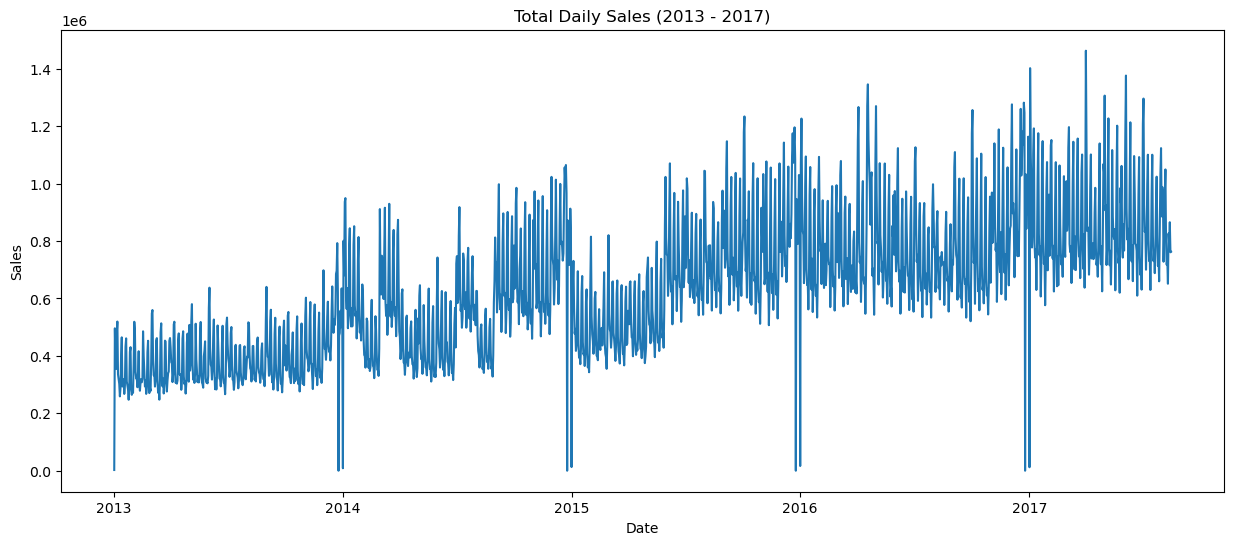

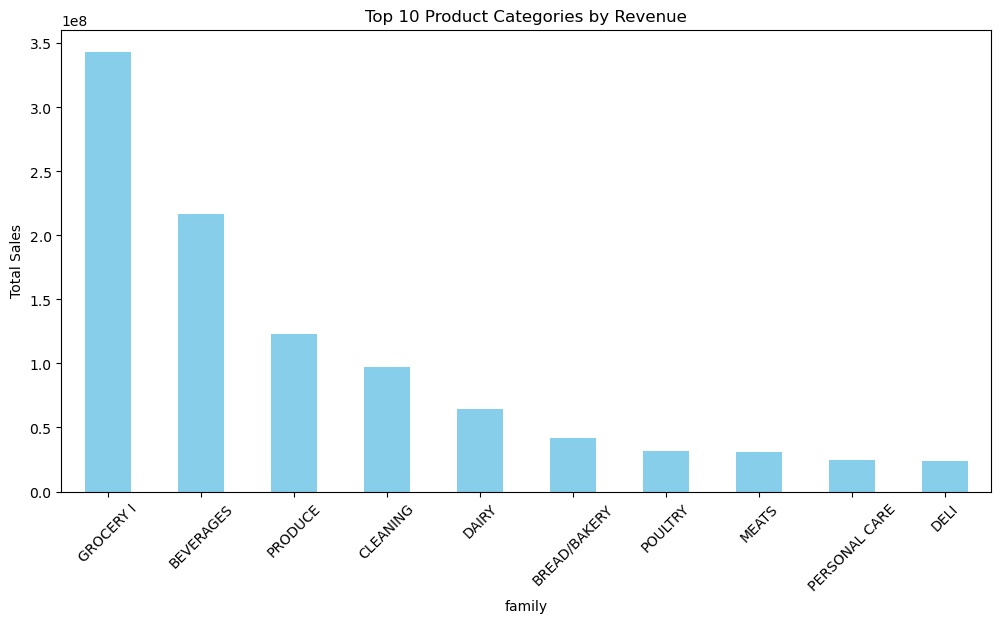

In [10]:
# 3.1.Total Daily Sales
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_sales, x='date', y='sales')
plt.title('Total Daily Sales (2013 - 2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# 3.2. Sales by Product Category (Family)
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
family_sales.plot(kind='bar', color='skyblue')
plt.title('Top 10 Product Categories by Revenue')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

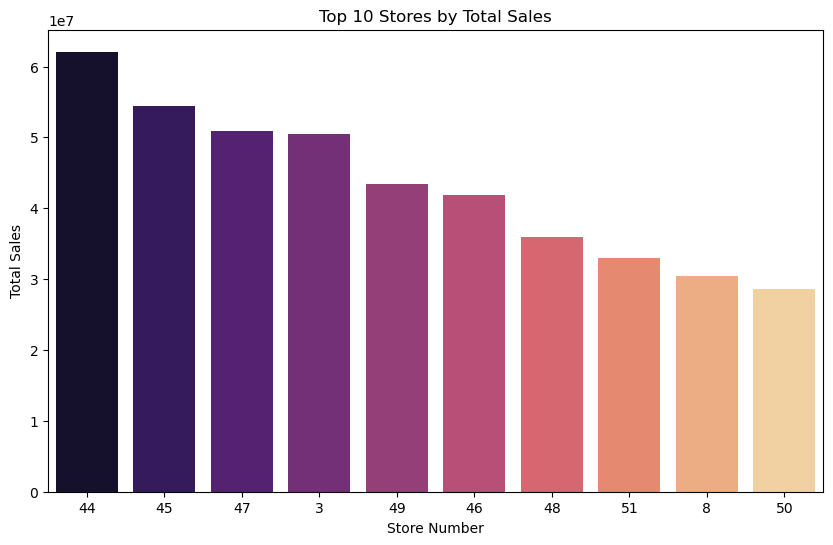

In [11]:
store_sales = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=store_sales, x='store_nbr', y='sales', order=store_sales['store_nbr'], palette='magma')
plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.show()

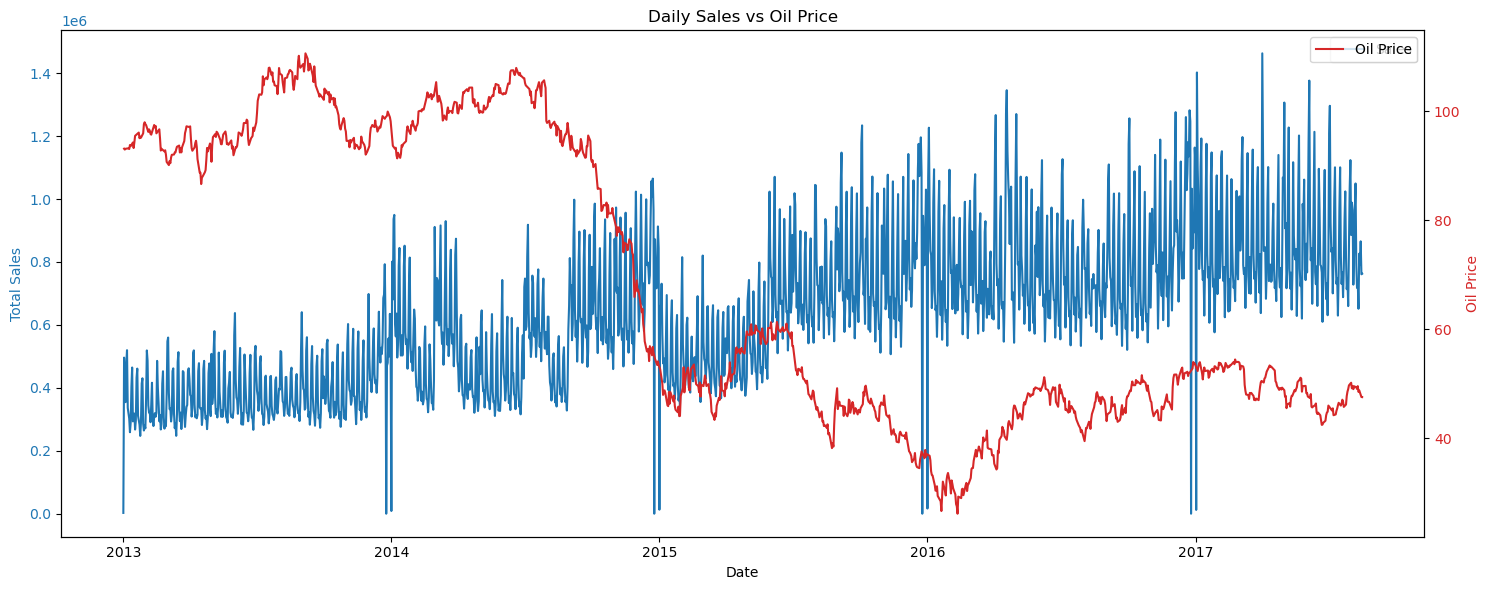

In [12]:
oil['date'] = pd.to_datetime(oil['date'])
daily_sales_oil = pd.merge(daily_sales, oil, on='date', how='left')

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Total Sales', color='tab:blue')
sns.lineplot(data=daily_sales_oil, x='date', y='sales', ax=ax1, color='tab:blue', label='Sales')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Oil Price', color='tab:red')
sns.lineplot(data=daily_sales_oil, x='date', y='dcoilwtico', ax=ax2, color='tab:red', label='Oil Price')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Daily Sales vs Oil Price')
fig.tight_layout()
plt.show()

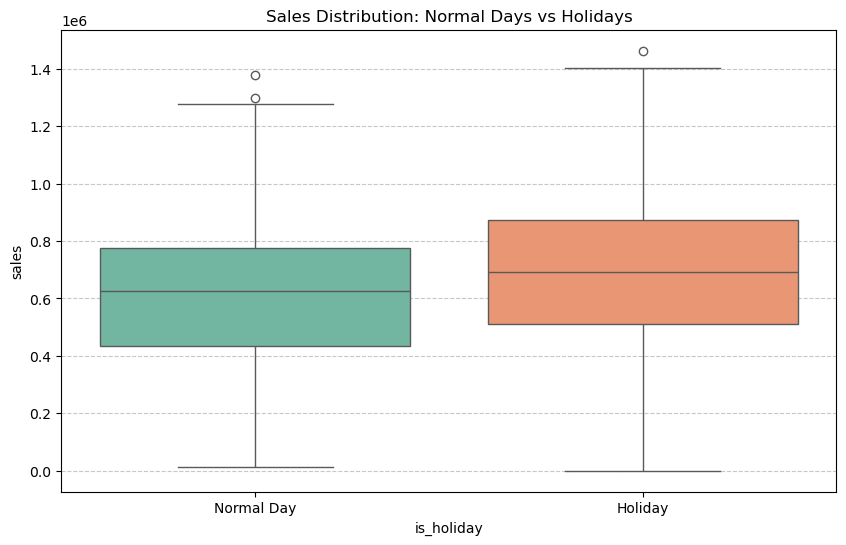

Average Non-Holiday Sales: 627,095.80
Average Holiday Sales: 696,497.08


In [13]:
# Preprocessing holiday data
holidays['date'] = pd.to_datetime(holidays['date'])
# Filter out transferred holidays to focus on days when the holiday actually happened
real_holidays = holidays[holidays['transferred'] == False]

# Merge with daily sales
sales_holiday = pd.merge(daily_sales, real_holidays[['date', 'type', 'locale']], on='date', how='left')
sales_holiday['is_holiday'] = sales_holiday['type'].notna()

# Visualizing the difference
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales_holiday, x='is_holiday', y='sales', palette='Set2')
plt.title('Sales Distribution: Normal Days vs Holidays')
plt.xticks([0, 1], ['Normal Day', 'Holiday'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

mean_normal = sales_holiday[sales_holiday['is_holiday']==False]['sales'].mean()
mean_holiday = sales_holiday[sales_holiday['is_holiday']==True]['sales'].mean()
print(f"Average Non-Holiday Sales: {mean_normal:,.2f}")
print(f"Average Holiday Sales: {mean_holiday:,.2f}")

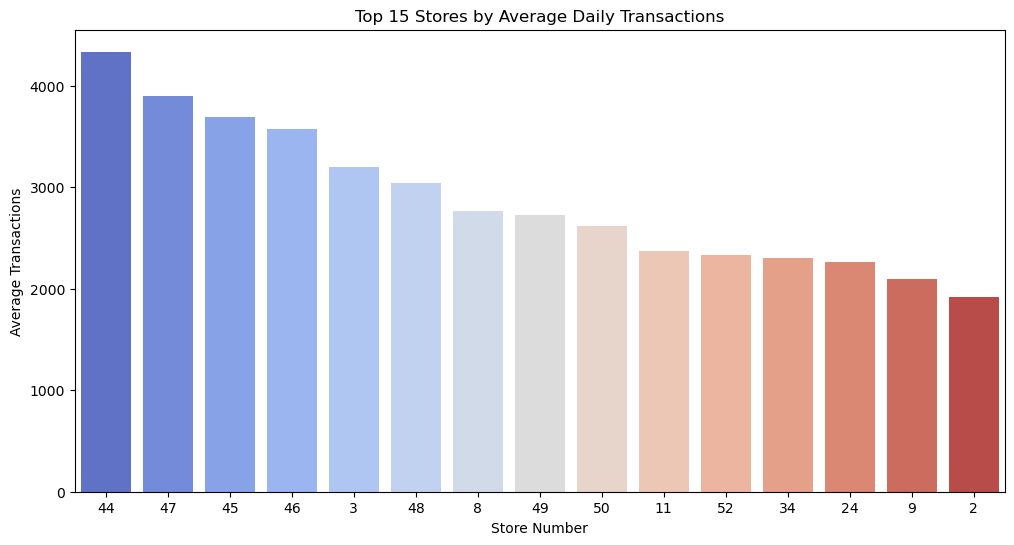

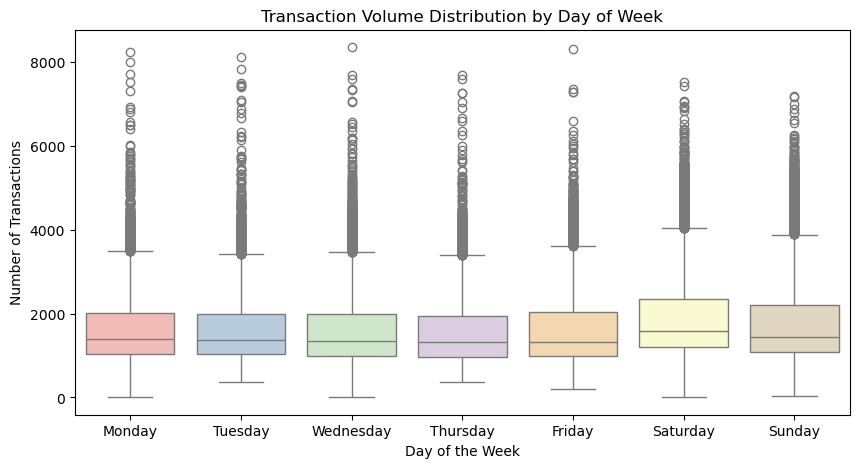

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Busiest Stores by Average Daily Transactions
avg_transactions = transactions.groupby('store_nbr')['transactions'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_transactions.head(15), x='store_nbr', y='transactions', order=avg_transactions.head(15)['store_nbr'], palette='coolwarm')
plt.title('Top 15 Stores by Average Daily Transactions')
plt.xlabel('Store Number')
plt.ylabel('Average Transactions')
plt.show()

# 2. Transaction Patterns by Day of Week
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['day_of_week'] = transactions['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(data=transactions, x='day_of_week', y='transactions', order=day_order, palette='Pastel1')
plt.title('Transaction Volume Distribution by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.show()

# Feature Engineering

- Handling Holidays
- Handling Oil Prices
- Handling Seasonality
- Handling Transactions
- Handling Other Events

In [15]:
df_all['sales'] = np.log1p(df_all['sales'])

## Xử lý Ngày lễ

In [16]:
temp_holidays = holidays.copy()
if 'type' in temp_holidays.columns:
    temp_holidays = temp_holidays.rename(columns={'type': 'holiday_type'})

temp_holidays['date'] = pd.to_datetime(temp_holidays['date'])


# (Transferred)
if 'transferred' in temp_holidays.columns:
    temp_holidays = temp_holidays[temp_holidays['transferred'] == False]

temp_holidays['priority'] = temp_holidays['locale'].map({'National': 1, 'Regional': 2, 'Local': 3}).fillna(4)
temp_holidays = temp_holidays.sort_values(by=['date', 'priority'])
temp_holidays = temp_holidays.drop_duplicates(subset=['date'], keep='first').drop(columns=['priority'])

df_all = df_all.merge(temp_holidays[['date', 'holiday_type', 'locale', 'locale_name']], on='date', how='left')


is_real_holiday = df_all['holiday_type'] != 'Work Day'

df_all['is_national_holiday'] = ((df_all['locale'] == 'National') & is_real_holiday).fillna(0).astype(int)
df_all['is_event'] = ((df_all['holiday_type'] == 'Event') & is_real_holiday).fillna(0).astype(int)

# Mapping logic 
mapping_dict = {
    'Quito': 'Quito', 'Cuenca': 'Cuenca', 'Manta': 'Manta', 'Libertad': 'Libertad', 'Riobamba': 'Riobamba',
    'Puyo': 'Puyo', 'Guaranda': 'Guaranda', 'Ambato': 'Ambato', 'Ibarra': 'Ibarra', 'Quevedo': 'Quevedo',
    'Esmeraldas': 'Esmeraldas', 'El Carmen': 'El Carmen', 'Guayaquil': 'Guayaquil', 'Loja': 'Loja',
    'Pichincha': 'Quito', 'Santo Domingo de los Tsachilas': 'Santo Domingo de los Tsachilas',
    'Cotopaxi': 'Cotopaxi', 'Imbabura': 'Imbabura', 'Santa Elena': 'Santa Elena', 'Manabi': 'Manta'
}

df_all['locale_match'] = df_all['city'].map(mapping_dict).fillna(df_all['state'].map(mapping_dict))
df_all['is_local_holiday'] = ((df_all['locale_name'] == df_all['locale_match']) & is_real_holiday).fillna(0).astype(int)

df_all['is_store_holiday'] = ((df_all['is_national_holiday'] == 1) | (df_all['is_local_holiday'] == 1)).astype(int)

df_all.loc[df_all['holiday_type'] == 'Work Day', 'is_weekend'] = 0

df_all = df_all.drop(columns=['locale_match', 'locale', 'locale_name', 'holiday_type'])

## Xử lí giá dầu

In [17]:
full_oil_dates = pd.date_range(start=df_all['date'].min(), end=df_all['date'].max())

oil_full = (
    oil.set_index('date')
    .reindex(full_oil_dates)       
    .reset_index()
    .rename(columns={'index': 'date'})
)

# Bây giờ hàm nội suy sẽ điền giá trị của ngày thứ Sáu vào cho thứ Bảy và Chủ Nhật một cách mượt mà
oil_full['dcoilwtico'] = oil_full['dcoilwtico'].interpolate(method='linear', limit_direction='both')

# Tính toán cú sốc giá dầu dựa trên chuỗi ngày liên tục thực tế (28 ngày chuẩn chỉnh)
oil_full['oil_price_shock'] = (oil_full['dcoilwtico'] / oil_full['dcoilwtico'].rolling(28, min_periods=1).mean()) - 1

# Thêm một đặc trưng bổ trợ: Xu hướng giá dầu ngắn hạn (so với 7 ngày trước)
oil_full['oil_biweekly_change'] = oil_full['dcoilwtico'] - oil_full['dcoilwtico'].shift(7)

# ==========================================
# Merge an toàn vào bảng tổng df_all (100% không lo dính NaN ngày cuối tuần)
# ==========================================
df_all = df_all.merge(
    oil_full[['date', 'dcoilwtico', 'oil_price_shock', 'oil_biweekly_change']], 
    on='date', 
    how='left'
)

## Time-based Feature Engineering

In [18]:
df_all['day_of_year'] = df_all['date'].dt.dayofyear
df_all["sin_day"] = np.sin(2 * np.pi * df_all["day_of_year"] / 365.25)
df_all["cos_day"] = np.cos(2 * np.pi * df_all["day_of_year"] / 365.25)
df_all['day_of_week'] = df_all['date'].dt.dayofweek
df_all['month'] = df_all['date'].dt.month
df_all['is_weekend'] = (df_all['day_of_week'] >= 5).astype(int)
df_all['day'] = df_all['date'].dt.day
day = df_all['date'].dt.day
last_day = df_all['date'].dt.days_in_month
df_all['is_payday'] = ((day == 15) | (day == last_day)).astype(int)
df_all['days_to_payday'] = np.where(day <= 15, 15 - day, last_day - day)
df_all['weekend_after_payday'] = ((df_all['is_weekend'] == 1) & (df_all['day'].isin([16, 17, 1, 2]))).astype(int)

df_all['is_closed'] = 0

# Tạo điều kiện cho ngày 1/1 và 25/12
is_new_year = (df_all['month'] == 1) & (df_all['day'] == 1)
is_christmas = (df_all['month'] == 12) & (df_all['day'] == 25)
df_all.loc[is_new_year | is_christmas, 'is_closed'] = 1

## Earthquake Data Processing

In [19]:
earthquake_date = pd.Timestamp("2016-04-16")
days_since_eq = (df_all['date'] - earthquake_date).dt.days
half_life = 7
df_all['earthquake_decay'] = np.where(
    days_since_eq >= 0,
    np.exp(-np.log(2) * days_since_eq / half_life),
    0
)

# 

In [20]:
avg_tra = transactions[transactions['date'] >= '2017-01-01'].groupby(['store_nbr', transactions['date'].dt.dayofweek])['transactions'].mean().reset_index()
avg_tra.columns = ['store_nbr', 'day_of_week', 'avg_tra_dow']
df_all = df_all.merge(avg_tra, on=['store_nbr', 'day_of_week'], how='left')

df_all = df_all.sort_values(by=['store_nbr', 'family', 'date']).reset_index(drop=True)

for lag in [1, 7, 14, 28, 364]:
    df_all[f'lag_{lag}'] = df_all.groupby(['store_nbr', 'family'])['sales'].shift(lag)

for window in [7, 28]:
    df_all[f'rolling_mean_{window}'] = df_all.groupby(['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

for window in [3, 7, 14]:
    df_all[f'promo_roll_{window}'] = df_all.groupby(['store_nbr', 'family'])['onpromotion'].transform(lambda x: x.rolling(window, min_periods=1).sum())


baseline = df_all[(df_all['date'] >= '2017-01-01') & (df_all['date'] < '2017-08-16')].groupby(['store_nbr', 'family', 'day_of_week'])['sales'].mean().reset_index(name='baseline_sales')

df_test_part = df_all[df_all['date'] >= '2017-08-16'].merge(baseline, on=['store_nbr', 'family', 'day_of_week'], how='left')

df_train_part = df_all[df_all['date'] < '2017-08-16'].copy()
df_train_part['baseline_sales'] = np.nan

df_all = pd.concat([df_train_part, df_test_part], axis=0).sort_values(by=['store_nbr', 'family', 'date']).reset_index(drop=True)

## Promotion Features

In [21]:
df_all = df_all.sort_values(by=['store_nbr', 'family', 'date']).reset_index(drop=True)
grouped_promo = df_all.groupby(['store_nbr', 'family'])['onpromotion']
df_all['promo_tomorrow'] = grouped_promo.shift(-1).fillna(0)
df_all['promo_yesterday'] = grouped_promo.shift(1).fillna(0)

In [22]:
df_all.columns

Index(['date', 'store_nbr', 'family', 'id', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_national_holiday', 'is_event',
       'is_local_holiday', 'is_store_holiday', 'is_weekend', 'dcoilwtico',
       'oil_price_shock', 'oil_biweekly_change', 'day_of_year', 'sin_day',
       'cos_day', 'day_of_week', 'month', 'day', 'is_payday', 'days_to_payday',
       'weekend_after_payday', 'is_closed', 'earthquake_decay', 'avg_tra_dow',
       'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_364', 'rolling_mean_7',
       'rolling_mean_28', 'promo_roll_3', 'promo_roll_7', 'promo_roll_14',
       'baseline_sales', 'promo_tomorrow', 'promo_yesterday'],
      dtype='object')

# Model

In [23]:
FEATURES = [
    'store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'oil_price_shock',
    'sin_day', 'cos_day', 'day_of_week', 'month', 'is_weekend',
    'is_payday', 'days_to_payday', 'earthquake_decay', 'type', 'cluster',
    'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_364',
    'rolling_mean_7', 'rolling_mean_28',
    'promo_roll_3', 'promo_roll_7', 'promo_roll_14',
    'baseline_sales', 'avg_tra_dow','promo_tomorrow', 'promo_yesterday'
]
CAT_FEATURES = ['family', 'store_nbr', 'type', 'cluster']

for col in CAT_FEATURES:
    df_all[col] = df_all[col].astype('category')

df_train_fit = df_all[(df_all['date'] >= '2017-01-01') & (df_all['sales'].notna())].dropna(subset=['lag_364'])

X_train_full = df_train_fit[FEATURES]
y_train_full = df_train_fit['sales']



In [24]:
model_lgbm_full = lgb.LGBMRegressor(
    n_estimators=1200, 
    learning_rate=0.015,
    num_leaves=63,
    max_depth=8,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# CatBoost
model_cat_full = CatBoostRegressor(
    iterations=2500,    
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=3,
    subsample=0.8,
    random_strength=0.5,
    random_state=42,
    verbose=False,
    allow_writing_files=False,
    task_type="CPU"
)


print("training LightGBM ...")
model_lgbm_full.fit(X_train_full, y_train_full)

print("training CatBoost ...")
model_cat_full.fit(X_train_full, y_train_full, cat_features=CAT_FEATURES)

print("✅ Training completed!")

training LightGBM ...
training CatBoost ...
✅ Training completed!


In [ ]:
test_dates = sorted(df_all[df_all['date'] >= '2017-08-16']['date'].unique())
print(f"Starting Ensemble Forecasting for {len(test_dates)} days...")

for pred_date in test_dates:
    for lag in [1, 7, 14, 28, 364]:
        df_all.loc[df_all['date'] == pred_date, f'lag_{lag}'] = df_all.groupby(['store_nbr', 'family'], observed=False)['sales'].shift(lag)
    for window in [7, 28]:
        df_all.loc[df_all['date'] == pred_date, f'rolling_mean_{window}'] = df_all.groupby(['store_nbr', 'family'], observed=False)['sales'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    
    mask = (df_all['date'] == pred_date)
    X_day = df_all[mask][FEATURES]
    
    pred_lgb = model_lgbm_full.predict(X_day)
    pred_cat = model_cat_full.predict(X_day)

    w_lgbm, w_cat = 0.4, 0.6
    df_all.loc[mask, 'sales'] = (pred_lgb * w_lgbm) + (pred_cat * w_cat)

df_all['sales_final'] = np.expm1(df_all['sales']).clip(lower=0)

# Zero-Rule & Sunday Boost
print("(Zero-Rule & Sunday Boost)...")
train_end_date = df_all[(df_all['date'] < '2017-08-16') & (df_all['sales'].notna())]['date'].max()
last_21_days = df_all[(df_all['date'] > (train_end_date - pd.Timedelta(days=21))) & (df_all['date'] <= train_end_date)]
zero_indices = last_21_days.groupby(['store_nbr', 'family'], observed=False)['sales_final'].sum().reset_index().query('sales_final == 0')

for _, row in zero_indices.iterrows():
    df_all.loc[(df_all['date'] >= '2017-08-16') & (df_all['store_nbr'] == row['store_nbr']) & (df_all['family'] == row['family']), 'sales_final'] = 0

df_all.loc[(df_all['date'] >= '2017-08-16') & (df_all['day_of_week'] == 6), 'sales_final'] *= 1.015

test_original = pd.read_csv('data/test.csv', parse_dates=['date'])
submission = test_original.merge(df_all[['date', 'store_nbr', 'family', 'sales_final']], on=['date', 'store_nbr', 'family'], how='left')
submission[['id', 'sales_final']].rename(columns={'sales_final': 'sales'}).to_csv('output/submission.csv', index=False)

print("Submission file exported!")

Starting Ensemble Forecasting for 16 days...
(Zero-Rule & Sunday Boost)...
Submission file exported!
